# Taller NoSQL y Visualización

Diseñado por: Maria Alejandra Angulo Mejia

En este cuaderno vamos a trabajar con bases de datos No SQL, revisaremos como se pueden manipular bases de datos documentales como lo es MongoDB desde Python, asi como la forma de generar visualizaciones que permitan entender mejor la base de datos.

Se tiene como prerequisito el desarrollo del taller 2 del curso.

La estructura de este cuaderno es la siguiente:

1) [Conexión a la base de datos](#conexion-a-la-base-de-datos)
    - Configurar el ambiente
2) [Visualización]()
    - Ejemplo visualización
    - Ejercicios visualización

Para conectar la base de datos de MongoDB se utilizará la librería [pymongo](https://pymongo.readthedocs.io/en/stable/tutorial.html). Para visualización de los datos se utilizara la la libreria de [Pandas](https://pandas.pydata.org/) y para la visualización  de los datos se usará [Seaborn](https://seaborn.pydata.org/) y [Matplotlib](https://matplotlib.org/).

En este cuaderno para el nombramiento de variables se utilizará la convención *snake_case*, esto para generar uniformidad en el código. Asimismo, procure que los nombres de sus variables sean indicativos para mejorar la legibilidad de su código.


# Conexion a la base de datos

## Configurar el ambiente

Esta configuración del ambiente supone que tiene instaladas las librerías pandas, seaborn y matplotlib; librerías instaladas durante el taller 2. En caso de no tener estas librerías, revise el taller 2 y realice la instalación.

Para realizar una conexión exitosa a la base de datos se requiere instalar ciertas dependencias en su máquina. Se puede hacer desde una terminal, corriendo el comando:

```bash
pip install pymongo
```

O corriendo la siguiente celda. Este paso solo debe realizarse una **única** vez. Una vez instaladas las dependencias no es necesario repetir el proceso.



In [ ]:
#Instalar librería pymongo
!pip install pymongo

Para familiarse más con la librería responda las siguientes preguntas.

¿Cómo funciona la librería pymongo?

¿Como se parece y se diferencia de oracledb?

Ya con el ambiente configurado se cargan las librerías necesarias para la ejecución apropiada de este cuaderno.

In [ ]:
#Importar librerías

#Pymongo
import pymongo
#Importar MongoClient para conectarse a la base de datos
from pymongo import MongoClient

#Pandas
import pandas as pd

#Seaborn
import seaborn as sns

#Matplotlib
import matplotlib.pyplot as plt


## Asociar credenciales para establecer la conexión a la base de datos MongoDB

Este cuaderno utiliza la base de datos NoSQL de Parranderos, por lo cual, como siguiente paso, debe ingresar las credenciales de MongoDB que le fueron compartidas.

In [ ]:
#Ingrese la URL de conexión a su base de datos MongoDB. MongoClient es la clase que nos permite establer la conexion a la base de datos.
cliente = MongoClient('mongodb://localhost:27017/')

#Conectar a la base de datos y sus colecciones. Debe cambiar 'parranderos' por el nombre exacto de su base de datos.
db = cliente['parranderos']

#Traer a memoria principal la información de las colecciones. Cambie el nombre por el nombre exacto de las colecciones que tiene en su base de datos (Ej Bares en vez de bares).
coleccion_bares = db['bares']
coleccion_bebedores = db['bebedores']

Realice una consulta para validar que está conectado a la base de datos y que tiene acceso a una colección. En este ejemplo, se van a traer los primeros 6 documentos relacionados con la colección de bares. Por esta razón, deben aparecer los 6 primeros bares del documento bares.

In [ ]:
#Extraer datos de la colección bares
cursor = coleccion_bares.find().limit(6)
# Convertir a DataFrame
df_grado_alcohol = pd.DataFrame(list(cursor))

# Mostrar
df_grado_alcohol

,_id,cant_sedes,ciudad,nombre,presupuesto,oferta_bebidas
0,58,7,Medellin,Bares Colombia,Bajo,NaN
1,59,5,Medellin,bar medellin,Bajo,NaN
2,60,5,Santa Marta,bar santa Marta,Bajo,"[{'nombre': 'cavernet', 'tipo': 'vino tinto', ..."
3,61,3,Santa Marta,bar santa Marta,Bajo,NaN
4,62,1,Bogotá,El Rincón Cubano,Alto,NaN
5,10,1,Barranquilla,Casa De La Cerveza,Bajo,"[{'nombre': 'cavernet', 'tipo': 'vino tinto', ..."


# Visualizacion

Para visualizar los datos de una base de datos documental se trabaja muy parecido que con una base de datos relacional, siempre y cuando se esté haciendo con DataFrames de Pandas. Sin embargo, en las bases NoSQL se requiere un paso adicional dado que Pandas no soporta las consultas de manera directa, como se muestra a continuación:

1) Generar el filtro. Puede ser a través de un pipeline o un find.

2) El resultado del filtro debe ser convertido en una lista para que Pandas pueda interpretarlo. Por lo tanto primero se guarda el resultado en una variable

3) La variable que devuelve el paso 2 se convierte en lista para luego convertirla en un DataFrame.

4) Sobre el DataFrame realizar las visualizaciones como se hizo en el taller 2.

Un ejemplo sobre el modelo de parranderos introducido al comienzo del cuaderno es:


```python
# 1) Crear el pipeline
pipeline = [
    {
        "$project": {
            "_id": 0,
            "nombre": 1,
            "cantidad_bebidas": { "$size": "$oferta_bebidas" }
        }
    },
    {
        "$sort": { "cantidad_bebidas": -1 }
    }
]
# 2) Guardar el resultado en una variable
resultado_cantidad_bebidas = coleccion_bares.aggregate(pipeline)
# 3) Convertir la variable en lista y la lista en DataFrame
df_bares = pd.DataFrame(list(resultado_cantidad_bebidas))

# 4) Graficar el DataFrame
plt.figure(figsize=(8, 5))
sns.barplot(data=df_bares, x="nombre", y="cantidad_bebidas")
plt.title("Cantidad de bebidas ofrecidas por bar")
plt.xlabel("Bar")
plt.ylabel("Bebidas")
plt.show()
```

## Visualización para bases de datos documentales

Con el propósito de estudiar como se pueden visualizar los datos de una base de datos documental se hace un ejercicio muy similar al realizado en el MPVG Taller 2. Por lo tanto se estudian diferentes casos de Parranderos.

1) Un inversor quiere comprar un bar en la ciudad con mayor número de sedes ya existentes (lo que puede indicar mercado sólido o competencia fuerte). ¿Qué gráfica le mostraría al inversor de marketing? ¿Qué le recomendaría?


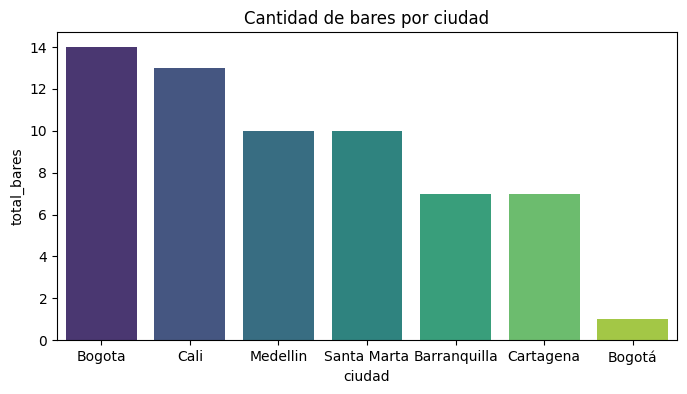

In [ ]:
pipeline = [
    {"$group": {"_id": "$ciudad", "total_bares": {"$sum": 1}}},
    {"$sort": {"total_bares": -1}}
]

resultado_total_bares = coleccion_bares.aggregate(pipeline)
df_total_bares = pd.DataFrame(list(resultado_total_bares))
df_total_bares.columns = ["ciudad", "total_bares"]

# Gráfico
plt.figure(figsize=(8, 4))
sns.barplot(data=df_total_bares, x="ciudad", y="total_bares", hue='ciudad',palette="viridis")
plt.title("Cantidad de bares por ciudad")
plt.show()

2)  Una empresa de bebidas quiere saber qué tipo de bebida (vino, cerveza, cóctel, etc.) es más común en la oferta de bares para lanzar una campaña. ¿Qué gráfica le mostraría a la empresa de bebidas? ¿Qué le recomendaría?

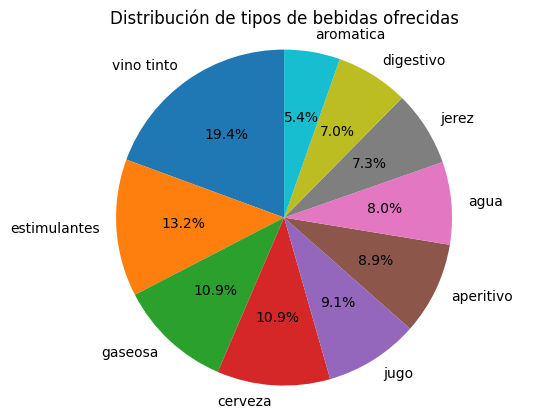

In [ ]:
pipeline = [
    {"$unwind": "$oferta_bebidas"},
    {"$group": {"_id": "$oferta_bebidas.tipo", "cantidad": {"$sum": 1}}},
    {"$sort": {"cantidad": -1}}
]

resultado_tipo_bebida = coleccion_bares.aggregate(pipeline)
df_tipo_bebida = pd.DataFrame(list(resultado_tipo_bebida))
df_tipo_bebida.columns = ["tipo_bebida", "cantidad"]

plt.pie(df_tipo_bebida["cantidad"], labels=df_tipo_bebida["tipo_bebida"], autopct="%1.1f%%", startangle=90)
plt.title("Distribución de tipos de bebidas ofrecidas")
plt.axis("equal")
plt.show()

3) Un grupo de salud pública quiere analizar qué tipos de bebidas suelen tener un mayor grado de alcohol, para orientar campañas de consumo responsable. ¿Qué gráfica le mostraría al grupo de salud pública? ¿Qué le recomendaría?

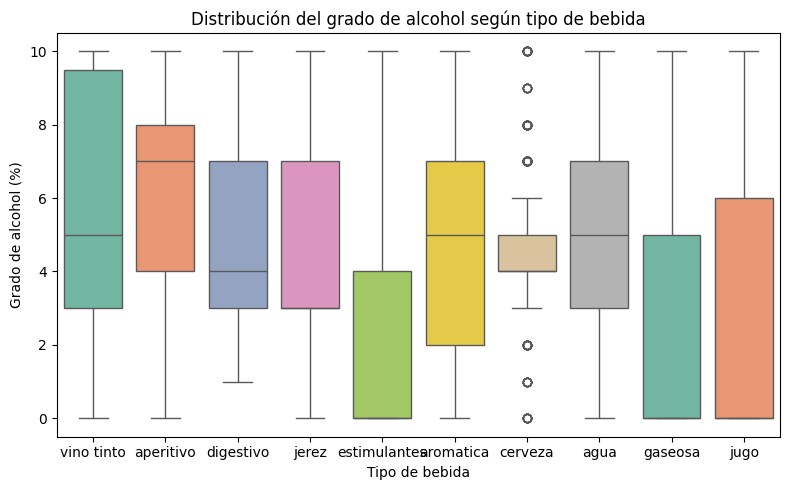

In [ ]:
pipeline = [
    {"$unwind": "$oferta_bebidas"},
    {"$project": {
        "_id": 0,
        "tipo": "$oferta_bebidas.tipo",
        "grado_alcohol": "$oferta_bebidas.grado_alcohol"
    }}
]

resultado_grado_alcohol = coleccion_bares.aggregate(pipeline)
df_grado_alcohol = pd.DataFrame(list(resultado_grado_alcohol))

plt.figure(figsize=(8,5))
sns.boxplot(data=df_grado_alcohol, x="tipo", y="grado_alcohol", hue= "tipo", palette="Set2")
plt.title("Distribución del grado de alcohol según tipo de bebida")
plt.xlabel("Tipo de bebida")
plt.ylabel("Grado de alcohol (%)")
plt.tight_layout()
plt.show()


4) Un economista quiere entender cómo varían los precios de las bebidas según el horario de venta (por ejemplo, si las bebidas nocturnas son más caras). ¿Qué gráfica le mostraría al economista? ¿Qué le recomendaría?

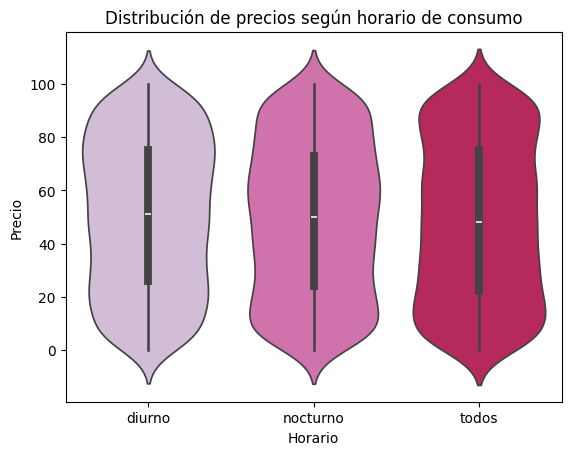

In [ ]:
pipeline = [
    {"$unwind": "$oferta_bebidas"},
    {"$project": {
        "_id": 0,
        "precio": "$oferta_bebidas.precio",
        "horario": "$oferta_bebidas.horario"
    }}
]

resultado_precios_bebida = list(coleccion_bares.aggregate(pipeline))
df_precios_bebida = pd.DataFrame(resultado_precios_bebida)

sns.violinplot(data=df_precios_bebida, x="horario", y="precio", hue = "horario",palette="PuRd")
plt.title("Distribución de precios según horario de consumo")
plt.xlabel("Horario")
plt.ylabel("Precio")
plt.show()
